In [1]:
from time import time
import mininumpy as mnp
import random
import matplotlib.pyplot as plt

In [2]:
n = [2, 3, 4, 5, 6, 7]
n_gau = [150, 160, 170, 180, 190, 200]

# Build test matrices
tests = [
    [mnp.Array([[random.random() for _ in range(N)] for _ in range(N)]) for N in n],
    [mnp.Array([[random.random() for _ in range(N)] for _ in range(N)]) for N in n_gau]
]

det = {}
timer = {}

for algo in ['recursion', 'LU', 'gaussian']:

    det[algo] = []
    timer[algo] = []

    # choose the correct test size group
    if algo == 'recursion':
        dataset = tests[0]      # small matrices
    else:
        dataset = tests[1]      # large matrices

    for i in range(len(dataset)):

        start = time()
        d = mnp.minilinalg.inv(dataset[i], algo=algo)
        stop = time()

        det[algo].append(d)
        timer[algo].append(stop - start)

In [3]:
print(timer)
print(det)

{'recursion': [0.0001125335693359375, 0.00015234947204589844, 0.00047016143798828125, 0.00135040283203125, 0.0033321380615234375, 0.007184505462646484], 'LU': [2.837388753890991, 3.3753254413604736, 4.055589437484741, 4.822968244552612, 5.711763143539429, 6.623315095901489], 'gaussian': [7.858190298080444, 9.330536365509033, 11.166202068328857, 16.448290824890137, 19.145856857299805, 20.149885416030884]}
{'recursion': [<mininumpy.array.Array object at 0x000001AD50B7FA10>, <mininumpy.array.Array object at 0x000001AD50B7E040>, <mininumpy.array.Array object at 0x000001AD50B7EDD0>, <mininumpy.array.Array object at 0x000001AD50B7ED60>, <mininumpy.array.Array object at 0x000001AD50B7EF20>, <mininumpy.array.Array object at 0x000001AD50B7EF90>], 'LU': [<mininumpy.array.Array object at 0x000001AD50B7E580>, <mininumpy.array.Array object at 0x000001AD50B7F000>, <mininumpy.array.Array object at 0x000001AD50B7EAC0>, <mininumpy.array.Array object at 0x000001AD50B7FD20>, <mininumpy.array.Array object

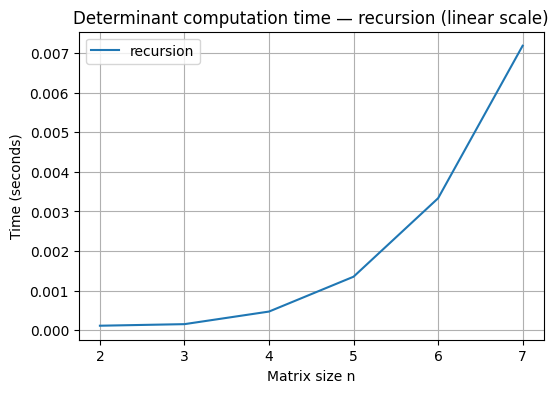

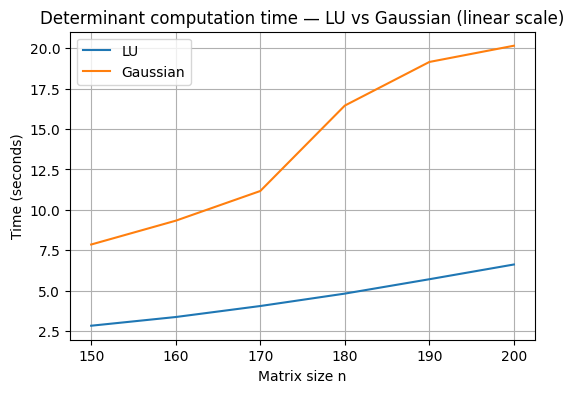

In [4]:
# --- Plot 1: recursion alone ---
plt.figure(figsize=(6,4))
plt.plot(n, timer["recursion"], label="recursion")
plt.xlabel("Matrix size n")
plt.ylabel("Time (seconds)")
plt.title("Determinant computation time — recursion (linear scale)")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot 2: LU + Gaussian together ---
plt.figure(figsize=(6,4))
plt.plot(n_gau, timer["LU"], label="LU")
plt.plot(n_gau, timer["gaussian"], label="Gaussian")
plt.xlabel("Matrix size n")
plt.ylabel("Time (seconds)")
plt.title("Determinant computation time — LU vs Gaussian (linear scale)")
plt.legend()
plt.grid(True)
plt.show()